48000
12586141
Downsampling data by a factor of 1000...
(312, 12586000)
Downsampled array shape: (312, 12586)
Creating heatmap...


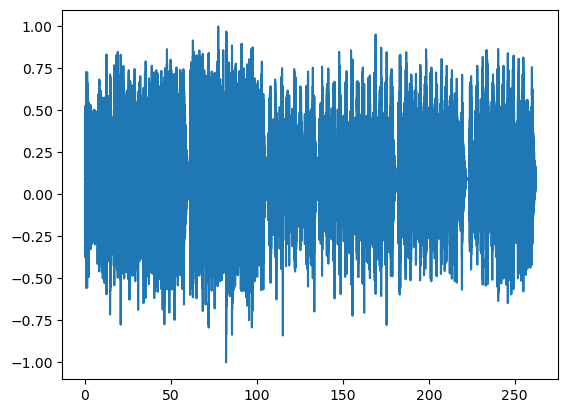

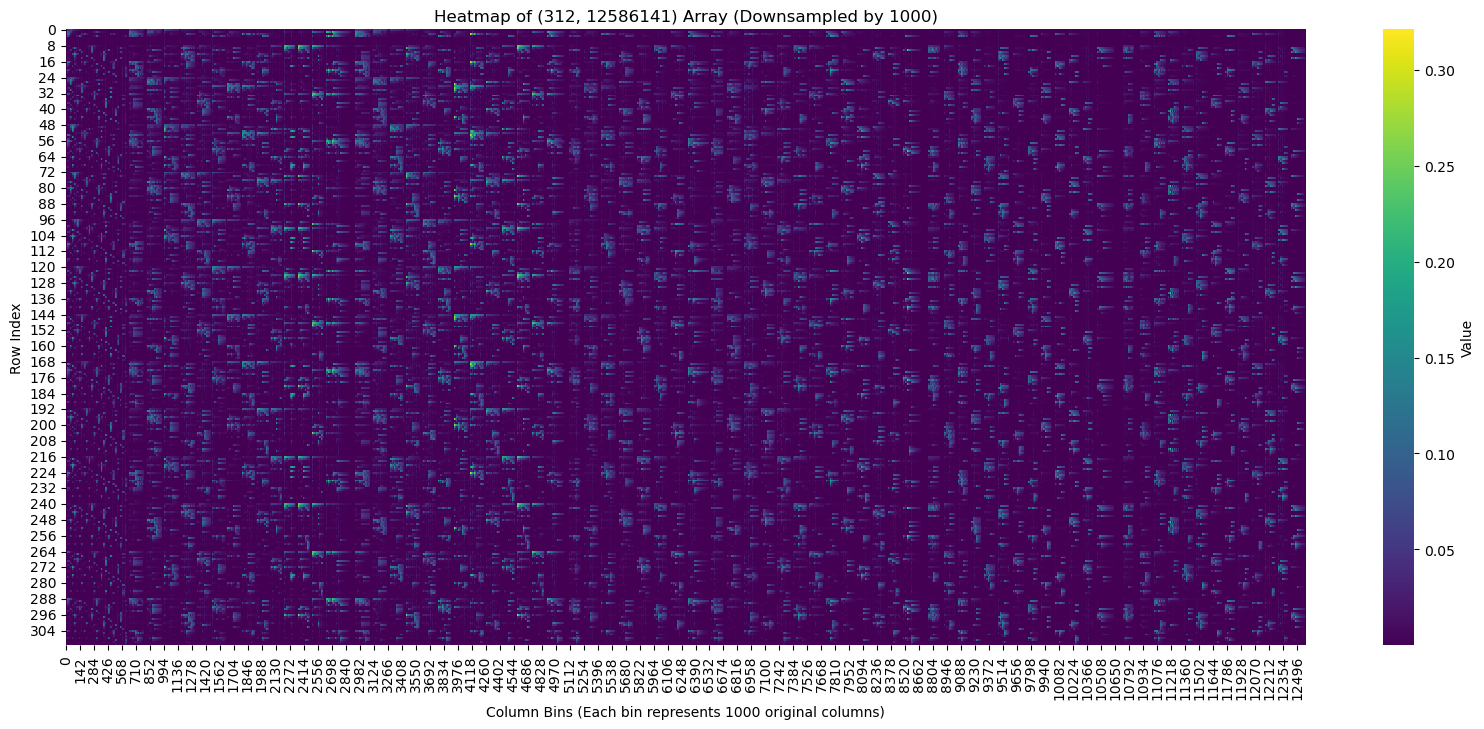

Heatmap displayed.
reshape data by a factor of 256...
(312, 12585984)
Reshaped the input data to  
(49164, 256, 312, 1)


In [ ]:
from scipy import io
from fretboard import FretBoard
import numpy
import matplotlib.pyplot as plt
import wave
from common import plot_heatmap,reshape_to_nn_input
sampleRate,input_signal_test=io.wavfile.read('../../assets/testdata/E-G-A-B-chords.wav')
# sampleRate,input_signal_test=io.wavfile.read('../../assets/trainingdata/chords/session_original.wav')
print(sampleRate)
filter=FretBoard(20,sampleRate)
numfilters=filter.get_num_filters()
audio_test=input_signal_test#[:,1];

audiomin=numpy.min(audio_test)
audiomax=numpy.max(audio_test)

audio_test=numpy.multiply((audio_test-audiomin)/(audiomax-audiomin),2)-1
print(len(audio_test))
nFrames =input_signal_test.shape[0]
time=numpy.linspace(0,len(audio_test)/sampleRate,len(audio_test))

plt.plot(time, audio_test, label='Input')

filterbank_out_test=numpy.zeros((numfilters,len(audio_test)))

filter.process(audio_test,filterbank_out_test)

plot_heatmap(filterbank_out_test)

nn_input_test=reshape_to_nn_input(filterbank_out_test)

In [18]:
from common import INPUT_SHAPE,OUTPUT_DIM_NOTES,OUTPUT_DIM_ONSETS
import numpy as np
from model import build_cnn_model
print(nn_input_test.shape)
print(INPUT_SHAPE)
cnn_model=build_cnn_model(INPUT_SHAPE,OUTPUT_DIM_NOTES)
cnn_model.load_weights('/home/gmwangi/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/guitarmidi.weights.h5')
# dummy_filter_outputs_2d = nn_input_test.reshape(nn_input_test.shape[0],nn_input_test.shape[1],nn_input_test.shape[2])#np.random.rand(256, 288).astype(np.float32)

# print(dummy_filter_outputs_2d.shape)

# # Reshape for the model: (batch_size, time_steps, num_filters, channels)
# # For single inference, batch_size = 1, channels = 1
# input_for_model = np.expand_dims(dummy_filter_outputs_2d[int(200000/256)], axis=0)  # Add batch dimension

# print(input_for_model.shape)
# input_for_model = np.expand_dims(input_for_model, axis=-1) # Add channel dimension

# print(input_for_model.shape)
outsample=40000
predictions_cnn = cnn_model.predict(nn_input_test, verbose=0)

predictions_cnn=np.swapaxes(predictions_cnn,0,1)
print(predictions_cnn.shape)
pred=np.repeat(predictions_cnn,256,axis=1)
print(pred.shape)
plot_heatmap(pred)

# print(predictions_cnn)
xpred=range(1,len(predictions_cnn))
print(len(predictions_cnn))
print(predictions_cnn.shape)
plt.plot(predictions_cnn[int(outsample/256)])
plt.show()

# plt.plot(nn_output[int(outsample/256)])

(49164, 256, 312, 1)
(256, 312, 1)


2025-07-16 21:13:49.557682: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 15707308032 exceeds 10% of free system memory.
2025-07-16 21:14:04.505126: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 14.63GiB (rounded to 15707308032)requested by op _EagerConst
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2025-07-16 21:14:04.505175: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1058] BFCAllocator dump for GPU_0_bfc
2025-07-16 21:14:04.505185: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1065] Bin (256): 	Total Chunks: 113, Chunks in use: 112. 28.2KiB allocated for chunks. 28.0KiB in use in bin. 13.6KiB client-requested in use in bin.
2025-07-16 21:14:04.505192: I external/local_xla/xla/tsl/framework/bfc_allo

InternalError: Failed copying input tensor from /job:localhost/replica:0/task:0/device:CPU:0 to /job:localhost/replica:0/task:0/device:GPU:0 in order to run _EagerConst: Dst tensor is not initialized.

In [ ]:
import numpy as np

# Let's say your original matrix is:
A = np.random.rand(4000, 89)  # just as an example matrix

# Repeat each row 256 times
A_expanded = np.repeat(A, 256, axis=0)  # shape will be (4000*256, 89)

print(A_expanded.shape)  # Output: (1024000, 89)


(4000, 22784)
